In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap

In [52]:
file_path = "Count.xlsx"
sheets = pd.read_excel(file_path, sheet_name=None)

df_bc = sheets['Big Colonies']
df_sp = sheets['Sparse']
df_ot = sheets['Others']

all_results = {}
all_ci = {}

In [53]:
# Define statistic
def metric_statistic(tp, fp, fn):
    precision = np.sum(tp) / (np.sum(tp) + np.sum(fp))
    recall = np.sum(tp) / (np.sum(tp) + np.sum(fn))
    f1 = 2 * precision * recall / (precision + recall)
    return np.array([precision, recall, f1])

def bootstrapping(df):
    tp = df["TP"].dropna().to_numpy()
    fp = df["FP"].dropna().to_numpy()
    fn = df["FN"].dropna().to_numpy()
    gt = df['Ground Truth'].dropna().to_numpy()


    result = bootstrap(
        (tp, fp, fn),
        metric_statistic,
        paired=True,
        n_resamples=10000, 
        confidence_level=0.95,
        method='BCa'
    )

    obs  = metric_statistic(tp, fp, fn)
    low  = result.confidence_interval.low
    high = result.confidence_interval.high

    print(f"Precision: {obs[0]:.4f} [{low[0]:.4f}, {high[0]:.4f}]")
    print(f"Recall:    {obs[1]:.4f} [{low[1]:.4f}, {high[1]:.4f}]")
    print(f"F1:        {obs[2]:.4f} [{low[2]:.4f}, {high[2]:.4f}]\n")
    return result


for i, (df, group) in enumerate(zip([df_bc, df_sp, df_ot], ["Big Colonies", "Sparse", "Others"])):
    print(group)
    result = bootstrapping(df)
    all_results[group] = result.bootstrap_distribution
    all_ci[group] = {
        "low": result.confidence_interval.low,
        "high": result.confidence_interval.high,
        "mean": metric_statistic(
            df["TP"].to_numpy(),
            df["FP"].to_numpy(),
            df["FN"].to_numpy())}

Big Colonies
Precision: 0.9553 [0.9183, 0.9797]
Recall:    0.7966 [0.7540, 0.8392]
F1:        0.8688 [0.8484, 0.8943]

Sparse
Precision: 0.9360 [0.8939, 0.9572]
Recall:    0.8351 [0.8089, 0.8607]
F1:        0.8826 [0.8578, 0.8992]

Others
Precision: 0.9726 [0.9603, 0.9822]
Recall:    0.8126 [0.7968, 0.8266]
F1:        0.8854 [0.8762, 0.8936]



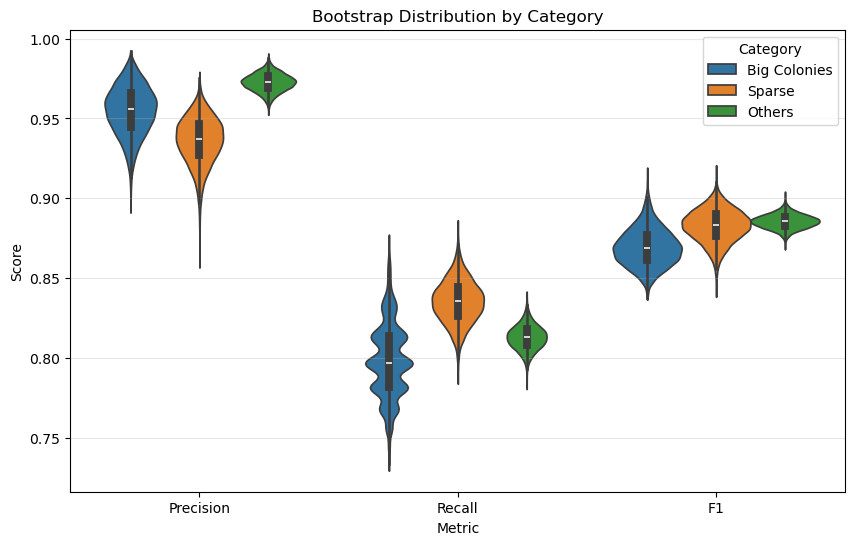

In [60]:
labels = ["Precision", "Recall", "F1"]
rows = []

for group, result in all_results.items():
    for i, metric in enumerate(labels):
        for val in result[i]:
            rows.append({
                "Category": group,
                "Metric": metric,
                "Score": val
            })

df = pd.DataFrame(rows)

plt.figure(figsize=(10,6))
ax = sns.violinplot(
    data=df,
    x="Metric",
    y="Score",
    hue="Category",
    inner="box",
    cut=0
)

plt.title("Bootstrap Distribution by Category")
plt.grid(axis="y", alpha=0.3)
plt.show()